In [4]:
# Import Library
import cv2 
import numpy as np
import os
import glob
from scipy.stats import skew
from typing import List, Tuple, Optional, Any

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
#Cek ada opencv dan surf nya ngga
print(f"OpenCV Version: {cv2.__version__}")
try:
    surf = cv2.xfeatures2d.SURF_create(300)
    print("Algoritma SURF tersedia dan siap digunakan!")
except Exception as e:
    print("ERROR: Algoritma SURF tidak tersedia. Pastikan opencv-contrib-python versi 3.4.2.16 terinstall.")

OpenCV Version: 3.4.2
Algoritma SURF tersedia dan siap digunakan!


In [6]:
#Konstanta Global
DATASET_PATH = 'dataset'  
RANDOM_STATE = 42
N_JOBS = 1  

In [7]:
# PRE-PROCESSING DAN EKSTRAKSI FITUR

def remove_background(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fungsi Adaptive Background Removal.
    Mampu membedakan antara gambar "Full Daging" dan "Berlatar Belakang",
    serta dilengkapi jaring pengaman (Safety Net).
    """
    tinggi, lebar = image.shape[:2]
    margin = 10 
    
    # Analisis tepi gambar apakah Full Daging atau Ada Background?
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Ambil piksel-piksel di 4 sisi paling pinggir gambar
    top = hsv[0:margin, :]
    bottom = hsv[tinggi-margin:tinggi, :]
    left = hsv[margin:tinggi-margin, 0:margin]
    right = hsv[margin:tinggi-margin, lebar-margin:lebar]
    
    # Gabungkan semua piksel pinggir untuk dianalisis
    border_pixels = np.concatenate([top.reshape(-1, 3), bottom.reshape(-1, 3), left.reshape(-1, 3), right.reshape(-1, 3)])
    
    # Hitung rata-rata Saturasi di pinggir gambar
    avg_sat = np.mean(border_pixels[:, 1]) 
    
    if avg_sat > 55: 
        # Langsung kembalikan gambar aslinya agar daging tidak terpotong.
        return image, np.ones(image.shape[:2], dtype=np.uint8) * 255
        
    # Jika ada background jalankan grabcut
    mask = np.zeros(image.shape[:2], np.uint8)
    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    rect = (margin, margin, lebar - 2*margin, tinggi - 2*margin)
    
    try:
        # Jalankan GrabCut dengan 5 iterasi agar lebih akurat untuk uji coba
        cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
        mask_daging = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
        
        # Safety Net Fallback
        persentase_sisa = (np.count_nonzero(mask_daging) / mask_daging.size) * 100
        
        if persentase_sisa < 15:
            return image, np.ones(image.shape[:2], dtype=np.uint8) * 255
            
        # Jika pemotongan wajar, haluskan pinggirannya
        kernel = np.ones((5,5), np.uint8)
        mask_daging = cv2.morphologyEx(mask_daging, cv2.MORPH_CLOSE, kernel)
        
        clean_mask = mask_daging * 255
        img_bersih = image * mask_daging[:, :, np.newaxis]
        
        return img_bersih, clean_mask
        
    except Exception as e:
        # Jika terjadi error sistem, kembalikan gambar asli
        return image, np.ones(image.shape[:2], dtype=np.uint8) * 255

def extract_hsv_features(image: np.ndarray, mask: Optional[np.ndarray] = None) -> np.ndarray:
    """Mengekstrak 57 dimensi fitur warna (9 Momen Warna + 48 Histogram 1D) dari ruang warna HSV."""
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    if mask is None:
        mask = np.ones(hsv_image.shape[:2], dtype=np.uint8) * 255
        
    valid_pixels_mask = mask > 0
    
    # 1. Ekstraksi Momen Warna (Mean, Std, Skewness) -> 9 Fitur
    color_moments = []
    for i in range(3):
        valid_pixels = hsv_image[:, :, i][valid_pixels_mask]
        if len(valid_pixels) > 0:
            color_moments.extend([np.mean(valid_pixels), np.std(valid_pixels), skew(valid_pixels)])
        else:
            color_moments.extend([0.0, 0.0, 0.0])
            
    # 2. Ekstraksi Histogram 1D (Hue, Saturation, Value) -> 48 Fitur
    hist_h = cv2.calcHist([hsv_image], [0], mask, [16], [0, 180])
    hist_s = cv2.calcHist([hsv_image], [1], mask, [16], [0, 256])
    hist_v = cv2.calcHist([hsv_image], [2], mask, [16], [0, 256])
    
    cv2.normalize(hist_h, hist_h)
    cv2.normalize(hist_s, hist_s)
    cv2.normalize(hist_v, hist_v)
    
    hist_features = np.concatenate([hist_h.flatten(), hist_s.flatten(), hist_v.flatten()])
    
    return np.concatenate([color_moments, hist_features])

def extract_surf_descriptors(image: np.ndarray) -> Optional[np.ndarray]:
    """Mendeteksi dan menghitung deskriptor SURF dari sebuah citra."""
    surf_extractor = cv2.xfeatures2d.SURF_create(300) 
    _, descriptors = surf_extractor.detectAndCompute(image, None)
    return descriptors

def create_bovw_histogram(descriptor: Optional[np.ndarray], kmeans_model: MiniBatchKMeans) -> np.ndarray:
    """Memetakan deskriptor SURF ke dalam kamus visual (BoVW) untuk membentuk histogram tekstur."""
    if descriptor is not None:
        visual_words = kmeans_model.predict(descriptor)
        histogram, _ = np.histogram(visual_words, bins=np.arange(kmeans_model.n_clusters + 1), density=True)
        return histogram
    return np.zeros(kmeans_model.n_clusters)

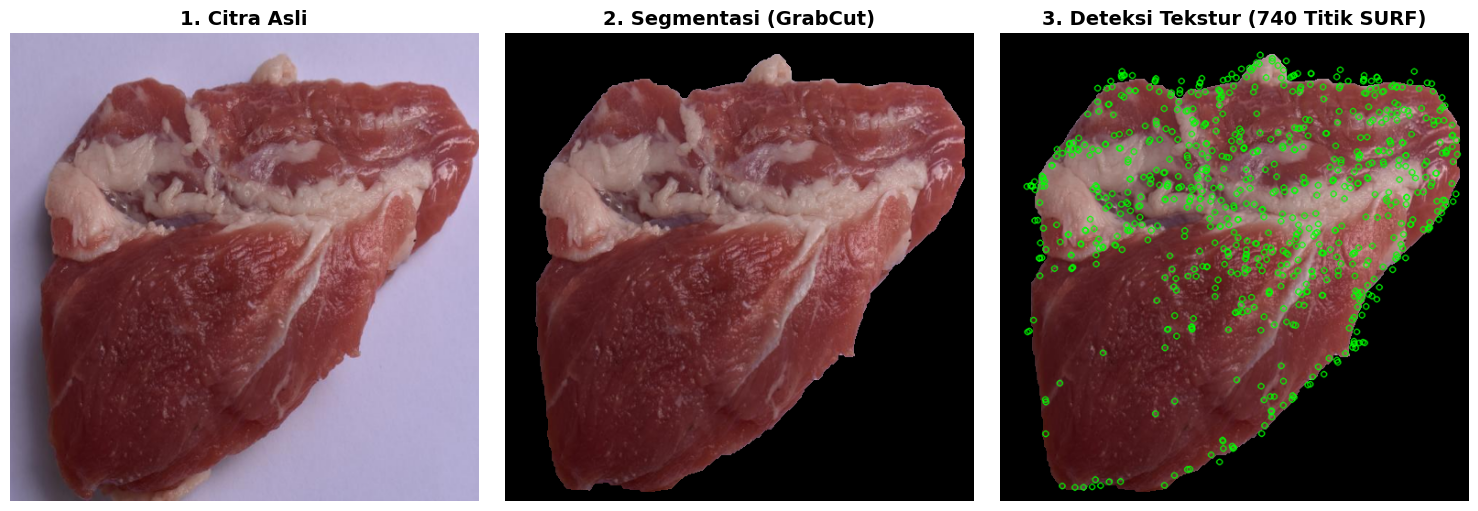

In [8]:
# VISUALISASI PRE-PROCESSING (GRABCUT) & TEKSTUR (SURF)
import matplotlib.pyplot as plt
import cv2

# Ganti dengan path salah satu gambar yang ada di komputer Anda
nama_file_uji = "dataset/Segar/1-23-_JPG.rf.e3e6d16fd20d135bf4b68eb2bd0175ca.jpg" 

img_asli = cv2.imread(nama_file_uji)

if img_asli is None:
    print(f"Eror: File gambar '{nama_file_uji}' tidak ditemukan. Periksa nama & lokasinya.")
else:
    # 1. Resize dan Eksekusi GrabCut
    img_resized = cv2.resize(img_asli, (512, 512))
    img_bersih, mask_daging = remove_background(img_resized)
    
    # 2. Deteksi Keypoints SURF khusus untuk visualisasi
    surf = cv2.xfeatures2d.SURF_create(300)
    keypoints, _ = surf.detectAndCompute(img_bersih, None)
    
    # Menggambar titik hijau pada citra hasil GrabCut
    img_keypoints = cv2.drawKeypoints(img_bersih, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)
    
    # 3. Plot Hasil
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title('1. Citra Asli', fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(img_bersih, cv2.COLOR_BGR2RGB))
    plt.title('2. Segmentasi (GrabCut)', fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f'3. Deteksi Tekstur ({len(keypoints)} Titik SURF)', fontsize=14, fontweight='bold')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [9]:
#  PIPELINE EVALUASI & FEATURE WEIGHTER

class FeatureWeighter(BaseEstimator, TransformerMixin):
    """Custom Transformer untuk memberikan bobot spesifik pada rentang fitur HSV."""
    def __init__(self, hsv_weight: float = 1.0, num_hsv_features: int = 57):
        self.hsv_weight = hsv_weight
        self.num_hsv_features = num_hsv_features
        
    def fit(self, X: np.ndarray, y: Optional[np.ndarray] = None) -> 'FeatureWeighter':
        return self
        
    def transform(self, X: np.ndarray) -> np.ndarray:
        X_weighted = X.copy()
        X_weighted[:, :self.num_hsv_features] *= self.hsv_weight
        return X_weighted

def build_visual_vocabulary(image_paths: List[str], k: int = 100, image_size: Tuple[int, int] = (512, 512)) -> Optional[MiniBatchKMeans]:
    """Bikin model KMeans (Visual Vocabulary) dari kumpulan deskriptor SURF citra latih."""
    print(f"Membangun Kamus Visual Tekstur (K-Means K={k})...")
    all_descriptors = []
    
    for path in image_paths:
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, image_size)
            img_cleaned, _ = remove_background(img)
            des = extract_surf_descriptors(img_cleaned)
            if des is not None:
                all_descriptors.append(des)
    
    if not all_descriptors:
        return None
        
    stacked_descriptors = np.vstack(all_descriptors)
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=2000)
    kmeans.fit(stacked_descriptors)
    
    print("Visual Vocabulary selesai dibuat!")
    return kmeans

def load_dataset_and_extract_features(dataset_path: str, kmeans_model: MiniBatchKMeans, image_size: Tuple[int, int] = (512, 512)) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Memuat data dari folder kelas, melakukan ekstraksi, dan menyusun matriks fitur (X) serta target (y)."""
    X_fusion, X_hsv_only, X_surf_only, y = [], [], [], []
    classes = ['Segar', 'SetengahSegar', 'Busuk']
    label_map = {cls: i for i, cls in enumerate(classes)}
    
    print("\nMULAI EKSTRAKSI FITUR MENTAH")
    for cls in classes:
        folder_path = os.path.join(dataset_path, cls)
        img_paths = glob.glob(os.path.join(folder_path, "*.*"))
        print(f"Memproses kelas {cls} ({len(img_paths)} gambar)...")
        
        for path in img_paths:
            img = cv2.imread(path)
            if img is None: 
                continue
            
            img = cv2.resize(img, image_size)
            img_cleaned, mask = remove_background(img)
            
            feat_hsv = extract_hsv_features(img_cleaned, mask)
            des = extract_surf_descriptors(img_cleaned)
            feat_bovw = create_bovw_histogram(des, kmeans_model)
            
            X_fusion.append(np.concatenate([feat_hsv, feat_bovw]))
            X_hsv_only.append(feat_hsv)
            X_surf_only.append(feat_bovw)
            y.append(label_map[cls])
            
    return np.array(X_fusion), np.array(X_hsv_only), np.array(X_surf_only), np.array(y)

def evaluate_model_pipeline(X: np.ndarray, y: np.ndarray, is_fusion: bool = False) -> Tuple[float, np.ndarray, Any, dict]:
    """Mengevaluasi pipeline ML menggunakan Stratified K-Fold dan mengembalikan akurasi serta parameter terbaik."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    base_svm = SVC(random_state=RANDOM_STATE, class_weight='balanced', probability=True)

    if is_fusion:
        pipeline_search = Pipeline([
            ('scaler', StandardScaler()),
            ('weighter', FeatureWeighter()),
            ('svm', base_svm)
        ])
        param_grid = {
            'weighter__hsv_weight': [0.1, 0.5, 1.0, 1.5, 2.0, 3.0], 
            'svm__C': [0.1, 1, 10, 50, 100],
            'svm__gamma': ['scale', 0.1, 0.01, 0.001],
            'svm__kernel': ['rbf', 'linear'] 
        }
    else:
        pipeline_search = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', base_svm)
        ])
        param_grid = {
            'svm__C': [0.1, 1, 10, 100, 1000],
            'svm__gamma': ['scale', 0.1, 0.01],
            'svm__kernel': ['rbf']
        }

    grid_search = GridSearchCV(pipeline_search, param_grid, cv=cv, scoring='accuracy', n_jobs=N_JOBS)
    grid_search.fit(X, y)
    
    best_model = grid_search.best_estimator_
    y_pred = cross_val_predict(best_model, X, y, cv=cv, n_jobs=N_JOBS)
    accuracy = accuracy_score(y, y_pred) * 100
    
    # return accuracy, y_pred, best_model, grid_search.best_params_
    return accuracy, y_pred, best_model, grid_search

In [10]:
# MAIN PROGRAM

DATASET_PATH =  DATASET_PATH
K_CLUSTERS = 100
IMG_SIZE = (512, 512) 
CLASSES_NAME = ['Segar', 'SetengahSegar', 'Busuk']

all_image_paths = glob.glob(os.path.join(DATASET_PATH, "*", "*.*"))

if all_image_paths:
    print(f"Total Dataset Ditemukan: {len(all_image_paths)} gambar.")
    
    # 1. Bangun Kamus Visual (BoVW)
    vocab_model = build_visual_vocabulary(all_image_paths, k=K_CLUSTERS, image_size=IMG_SIZE)
    
    # 2. Ekstraksi Fitur
    X_fusi, X_hsv, X_surf, y_label = load_dataset_and_extract_features(DATASET_PATH, vocab_model, IMG_SIZE)
    
    
    print("PROSES PELATIHAN & EVALUASI MODEL (5-FOLD CV)")
    
    # 3. Skenario 1: Hanya SURF (Tekstur)
    print("\n[1/3] Menguji Model: HANYA TEKSTUR (SURF-BoVW)")
    acc_surf, pred_surf, _, params_surf = evaluate_model_pipeline(X_surf, y_label, is_fusion=False)
    print(f"-> Akurasi SURF: {acc_surf:.2f}% | Parameter Terbaik: {params_surf}")

    # 4. Skenario 2: Hanya HSV (Warna)
    print("\n[2/3] Menguji Model: HANYA WARNA (HSV 57 Fitur)")
    acc_hsv, pred_hsv, _, params_hsv = evaluate_model_pipeline(X_hsv, y_label, is_fusion=False)
    print(f"-> Akurasi HSV: {acc_hsv:.2f}% | Parameter Terbaik: {params_hsv}")

    # 5. Skenario 3: Fusi (Warna + Tekstur)
    print("\n[3/3] Menguji Model: FUSI FITUR")
    acc_fusi, pred_fusi, best_fusion_model, params_fusi = evaluate_model_pipeline(X_fusi, y_label, is_fusion=True)
    print(f"-> Akurasi FUSI: {acc_fusi:.2f}% | Parameter Terbaik: {params_fusi}")
    
    print("\nDONE")
else:
    print("ERROR: Dataset tidak ditemukan, cek path nya")

Total Dataset Ditemukan: 400 gambar.
Membangun Kamus Visual Tekstur (K-Means K=100)...
Visual Vocabulary selesai dibuat!

MULAI EKSTRAKSI FITUR MENTAH
Memproses kelas Segar (138 gambar)...
Memproses kelas SetengahSegar (130 gambar)...
Memproses kelas Busuk (132 gambar)...
PROSES PELATIHAN & EVALUASI MODEL (5-FOLD CV)

[1/3] Menguji Model: HANYA TEKSTUR (SURF-BoVW)
-> Akurasi SURF: 65.25% | Parameter Terbaik: GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=1,
             param_grid={'svm__C': [0.1, 1, 10, 100, 1000],
                         'svm__gamma': ['scale', 0.1, 0.01],
                         'svm__kernel': ['rbf']},
      

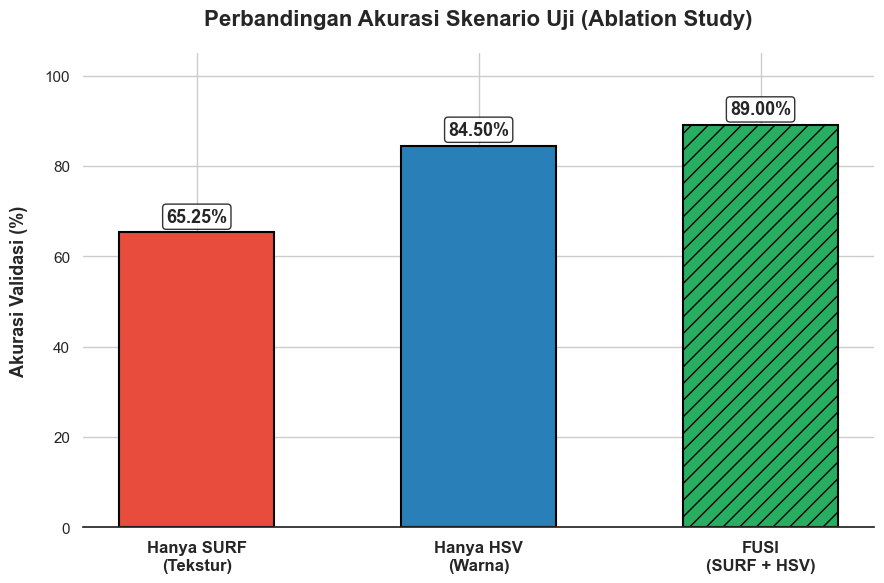

DETAIL PERFORMA MODEL TERBAIK (FUSI): 


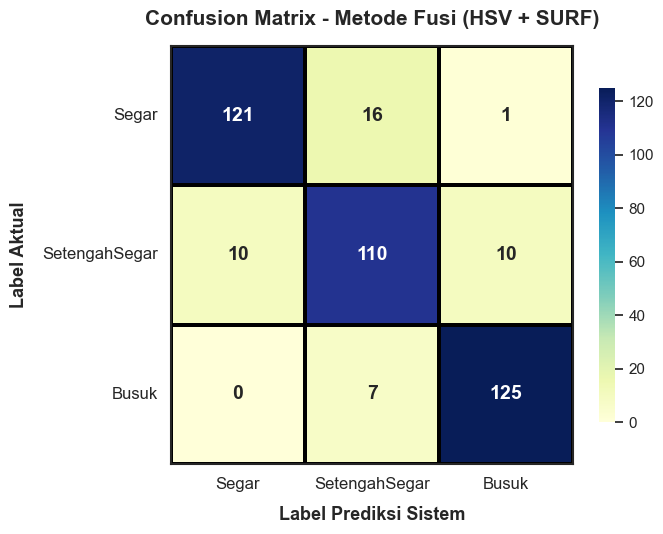


Laporan Klasifikasi Rinci:
               precision    recall  f1-score   support

        Segar       0.92      0.88      0.90       138
SetengahSegar       0.83      0.85      0.84       130
        Busuk       0.92      0.95      0.93       132

     accuracy                           0.89       400
    macro avg       0.89      0.89      0.89       400
 weighted avg       0.89      0.89      0.89       400



In [11]:
# VISUALISASI HASIL EVALUASI

def plot_accuracy_comparison(acc_hsv: float, acc_surf: float, acc_fusi: float):
    """Menampilkan grafik batang perbandingan akurasi."""
    import seaborn as sns
    
    # Mengaktifkan gaya grid
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "axes.linewidth": 1.25})
    
    methods = ['Hanya SURF\n(Tekstur)', 'Hanya HSV\n(Warna)', 'FUSI\n(SURF + HSV)']
    accuracies = [acc_surf, acc_hsv, acc_fusi]
    
    plt.figure(figsize=(9, 6))
    
    # Warna batang
    warna_bar = ['#e74c3c', '#2980b9', '#27ae60']
    
    # Menggambar grafik batang dengan garis tepi hitam tegas
    bars = plt.bar(methods, accuracies, color=warna_bar, edgecolor='black', linewidth=1.5, width=0.55)
    
    # Tambahkan pola arsiran (hatch) pada batang ke-3 (Fusi)
    bars[2].set_hatch('//')
    
    # Pengaturan sumbu Y agar proporsional
    plt.ylim(0, 105) 
    plt.ylabel('Akurasi Validasi (%)', fontsize=13, fontweight='bold', labelpad=12)
    plt.title('Perbandingan Akurasi Skenario Uji (Ablation Study)', fontsize=16, fontweight='bold', pad=20)
    
    # Menambahkan angka persentase di atas batang dengan kotak latar (Bbox) agar elegan
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.2f}%", 
                 ha='center', va='bottom', fontsize=13, fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2', alpha=0.8))
    
    # Mempercantik font label bawah
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=11)
    
    # Menghapus garis kotak atas dan kanan agar terlihat modern
    sns.despine(left=True, top=True, right=True) 
    
    plt.tight_layout()
    plt.show()

def plot_beautiful_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, classes: List[str], title: str):
    """Mencetak heatmap Confusion Matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(7, 5.5))
    
    # linewidths untuk memisahkan antar kotak
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                     xticklabels=classes, yticklabels=classes, 
                     annot_kws={"size": 14, "weight": "bold"},
                     linewidths=1.5, linecolor='black', cbar_kws={'shrink': .8})
    
    # Mempertebal bingkai matriks
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.ylabel('Label Aktual', fontsize=13, fontweight='bold', labelpad=10)
    plt.xlabel('Label Prediksi Sistem', fontsize=13, fontweight='bold', labelpad=10)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0) # Memastikan teks sumbu y tidak miring
    
    plt.tight_layout()
    plt.show()

# PEMANGGILAN GRAFIK
if 'acc_fusi' in locals():
    # 1. Tampilkan Grafik Batang Ablation Study
    plot_accuracy_comparison(acc_hsv, acc_surf, acc_fusi)
    
    # 2. Tampilkan Detail Laporan Model Fusi Terbaik
    print("DETAIL PERFORMA MODEL TERBAIK (FUSI): ")
    plot_beautiful_confusion_matrix(y_label, pred_fusi, CLASSES_NAME, 'Confusion Matrix - Metode Fusi (HSV + SURF)')
    
    print("\nLaporan Klasifikasi Rinci:")
    print(classification_report(y_label, pred_fusi, target_names=CLASSES_NAME))


CONFUSION MATRIX SKENARIO FITUR TUNGGAL


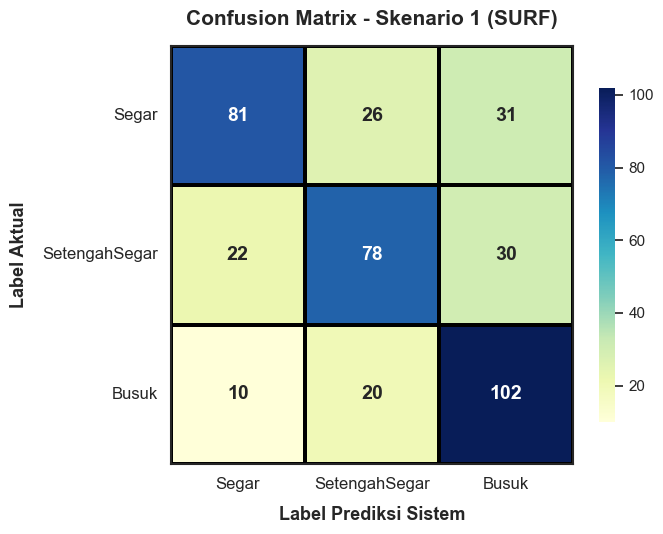

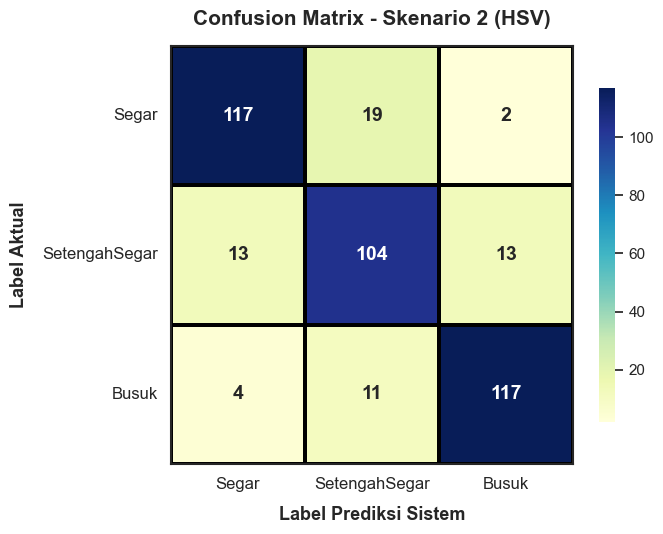

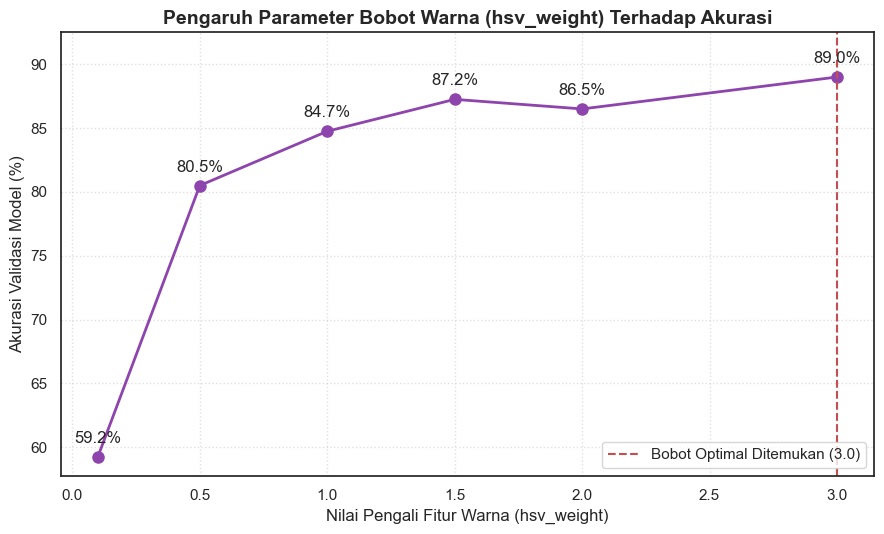

In [12]:
# VISUALISASI TAMBAHAN
import matplotlib.pyplot as plt
import pandas as pd

# 1. Confusion Matrix untuk Skenario 1 dan 2
print("\nCONFUSION MATRIX SKENARIO FITUR TUNGGAL")
plot_beautiful_confusion_matrix(y_label, pred_surf, CLASSES_NAME, 'Confusion Matrix - Skenario 1 (SURF)')
plot_beautiful_confusion_matrix(y_label, pred_hsv, CLASSES_NAME, 'Confusion Matrix - Skenario 2 (HSV)')

# 2. Fungsi Ekstrak dan Plot Grafik Pengaruh hsv_weight secara Dinamis
def plot_hsv_weight_impact_dynamic(grid_search_obj):
    """
    Menampilkan grafik pengaruh bobot warna (hsv_weight) secara dinamis 
    berdasarkan hasil paramater SVM terbaik yang ditemukan oleh GridSearch.
    """
    # Ambil hasil log training dari GridSearch
    results = pd.DataFrame(grid_search_obj.cv_results_)
    
    # Ambil parameter SVM terbaik yang baru saja ditemukan oleh model
    best_params = grid_search_obj.best_params_
    best_c = best_params['svm__C']
    best_kernel = best_params['svm__kernel']
    best_gamma = best_params['svm__gamma']
    best_optimal_weight = best_params['weighter__hsv_weight']
    
    # Filter tabel hanya untuk kombinasi parameter SVM terbaik
    filtered_res = results[(results['param_svm__kernel'] == best_kernel) & 
                           (results['param_svm__C'] == best_c) & 
                           (results['param_svm__gamma'] == best_gamma)]
    
    # Urutkan berdasarkan bobot (dari kecil ke besar)
    filtered_res = filtered_res.sort_values(by='param_weighter__hsv_weight')
    weights = filtered_res['param_weighter__hsv_weight'].tolist()
    scores = (filtered_res['mean_test_score'] * 100).tolist() 
        
    # Proses Penggambaran Grafik
    plt.figure(figsize=(9, 5.5))
    plt.plot(weights, scores, marker='o', linestyle='-', color='#8e44ad', linewidth=2, markersize=8)
    
    # Buat garis di titik bobot yang paling optimal
    plt.axvline(x=best_optimal_weight, color='r', linestyle='--', 
                label=f'Bobot Optimal Ditemukan ({best_optimal_weight})')
    plt.ylim(min(scores) - 1.5, max(scores) + 3.5)
    
    plt.title('Pengaruh Parameter Bobot Warna (hsv_weight) Terhadap Akurasi', fontsize=14, fontweight='bold')
    plt.xlabel('Nilai Pengali Fitur Warna (hsv_weight)', fontsize=12)
    plt.ylabel('Akurasi Validasi Model (%)', fontsize=12)
    
    # Anotasi angka akurasi di setiap titik koordinat
    for i, txt in enumerate(scores):
        plt.annotate(f"{txt:.1f}%", (weights[i], scores[i]), textcoords="offset points", xytext=(0,10), ha='center')
        
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Calling
try:
    plot_hsv_weight_impact_dynamic(params_fusi)
except NameError:
    print("Variabel grid_fusi belum ada. Pastikan Cell Pelatihan sudah dijalankan.")

In [13]:
# SAVE MODEL
import joblib
import os
from typing import Any

def save_trained_models(fusion_model: Any, kmeans_model: Any, save_dir: str = ".") -> None:
    """
    Menyimpan model yang sudah dilatih ke dalam file lokal (.pkl).
    
    
    Args:
        fusion_model (Any): Objek model SVM terbaik hasil dari proses GridSearchCV.
        kmeans_model (Any): Objek model K-Means yang menyimpan kamus visual (vocabulary) SURF.
        save_dir (str): Lokasi direktori/folder untuk menyimpan file. Default adalah "." / folder saat ini.
    """
    
    # Menentukan path file untuk masing-masing model
    svm_filename = os.path.join(save_dir, 'models/fusi_model.pkl')
    kmeans_filename = os.path.join(save_dir, 'models/kmeans_vocab.pkl')
    
    try:
        joblib.dump(fusion_model, svm_filename)
        print(f"[BERHASIL] Model klasifikasi SVM Fusi disimpan di: {svm_filename}")
        
        joblib.dump(kmeans_model, kmeans_filename)
        print(f"[BERHASIL] Model Kamus Visual (BoVW) disimpan di: {kmeans_filename}")
        
    except Exception as e:
        print(f"[GAGAL] Terjadi kesalahan saat menyimpan model: {e}")

# EKSEKUSI PENYIMPANAN
if 'best_fusion_model' in locals() and 'vocab_model' in locals():
    save_trained_models(best_fusion_model, vocab_model)
else:
    print("Perhatian: Model belum tersedia di memori. Pastikan sudah menjalankan Proses Pelatihan terlebih dahulu.")

[BERHASIL] Model klasifikasi SVM Fusi disimpan di: .\models/fusi_model.pkl
[BERHASIL] Model Kamus Visual (BoVW) disimpan di: .\models/kmeans_vocab.pkl


Start Prediction...

HASIL DIAGNOSIS SISTEM:
Prediksi Kesegaran : Segar
Tingkat Keyakinan  : 95.71%
Titik Tekstur SURF : 1840 keypoints


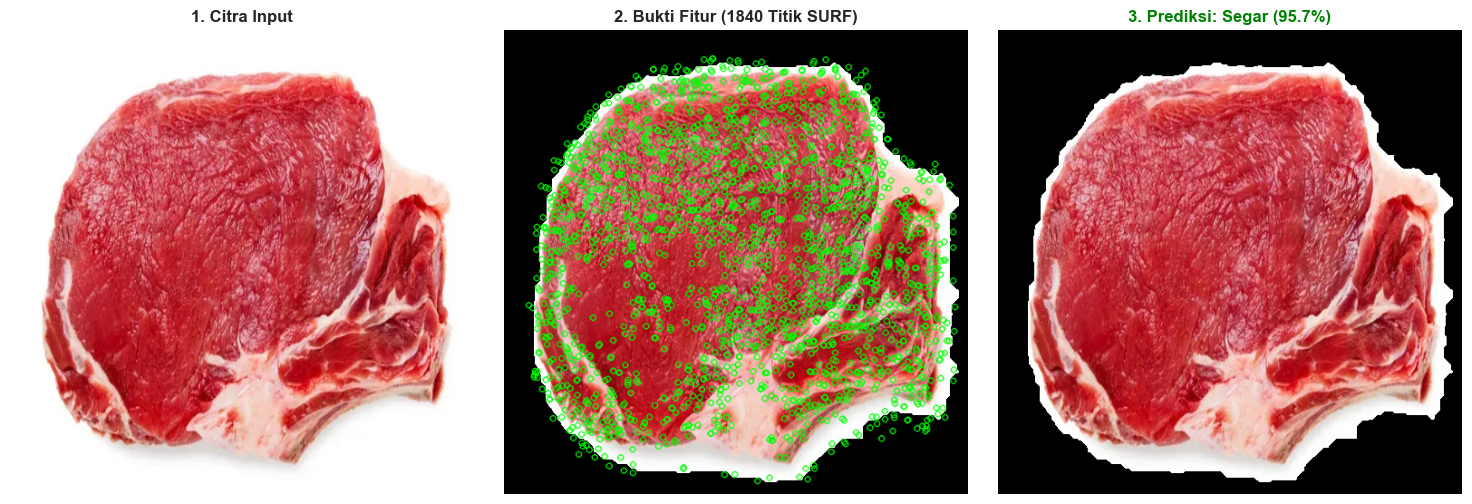

In [14]:
# UJI PREDIKSI
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

def uji_prediksi_gambar(image_path: str, svm_path: str, kmeans_path: str):
    print("Start Prediction...\n")
    
    try:
        model_fusi = joblib.load(svm_path)
        model_kmeans = joblib.load(kmeans_path)
    except Exception as e:
        print(f"❌ Gagal memuat model: {e}")
        return

    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Gambar tidak ditemukan di path: {image_path}")
        return

    # 1. Pre-processing
    img_resized = cv2.resize(img, (512, 512))
    img_bersih, mask = remove_background(img_resized)

    # 2. Ekstraksi Fitur
    fitur_hsv = extract_hsv_features(img_bersih, mask)
    deskriptor_surf = extract_surf_descriptors(img_bersih)
    fitur_tekstur = create_bovw_histogram(deskriptor_surf, model_kmeans)

    # Menangkap keypoints untuk digambar
    surf_vis = cv2.xfeatures2d.SURF_create(300)
    keypoints, _ = surf_vis.detectAndCompute(img_bersih, None)
    img_keypoints = cv2.drawKeypoints(img_bersih, keypoints, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DEFAULT)

    # 3. Klasifikasi (Fusi)
    fitur_gabungan = np.concatenate([fitur_hsv, fitur_tekstur]).reshape(1, -1)
    indeks_prediksi = model_fusi.predict(fitur_gabungan)[0]
    persentase_yakin = model_fusi.predict_proba(fitur_gabungan)[0][indeks_prediksi] * 100

    daftar_kelas = ['Segar', 'Setengah Segar', 'Busuk']
    hasil_kelas = daftar_kelas[indeks_prediksi]

    # 4. Tampilkan Laporan Teks
    print("HASIL DIAGNOSIS SISTEM:")
    print(f"Prediksi Kesegaran : {hasil_kelas}")
    print(f"Tingkat Keyakinan  : {persentase_yakin:.2f}%")
    print(f"Titik Tekstur SURF : {len(keypoints)} keypoints")

    # 5. Visualisasi 3 Kolom )
    plt.figure(figsize=(15, 5))

    # KOLOM 1: GAMBAR ASLI
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    plt.title("1. Citra Input", fontweight='bold')
    plt.axis('off')

    # KOLOM 2: BUKTI FITUR (TITIK SURF)
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f"2. Bukti Fitur ({len(keypoints)} Titik SURF)", fontweight='bold')
    plt.axis('off')

    # KOLOM 3: HASIL GRABCUT & PREDIKSI AKHIR
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(img_bersih, cv2.COLOR_BGR2RGB))
    warna_judul = 'green' if hasil_kelas == 'Segar' else 'orange' if hasil_kelas == 'Setengah Segar' else 'red'
    plt.title(f"3. Prediksi: {hasil_kelas} ({persentase_yakin:.1f}%)", fontweight='bold', color=warna_judul)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# sesuaikan path nya
PATH_GAMBAR_TEST = "test_img/segar4.webp" 
PATH_MODEL_SVM = "./models/fusi_model.pkl" 
PATH_MODEL_KMEANS = "./models/kmeans_vocab.pkl"

# Jalankan fungsi
uji_prediksi_gambar(PATH_GAMBAR_TEST, PATH_MODEL_SVM, PATH_MODEL_KMEANS)

Visualisasi berhasil dibuat dan disimpan sebagai: Gambar_3_Visualisasi_HSV.png


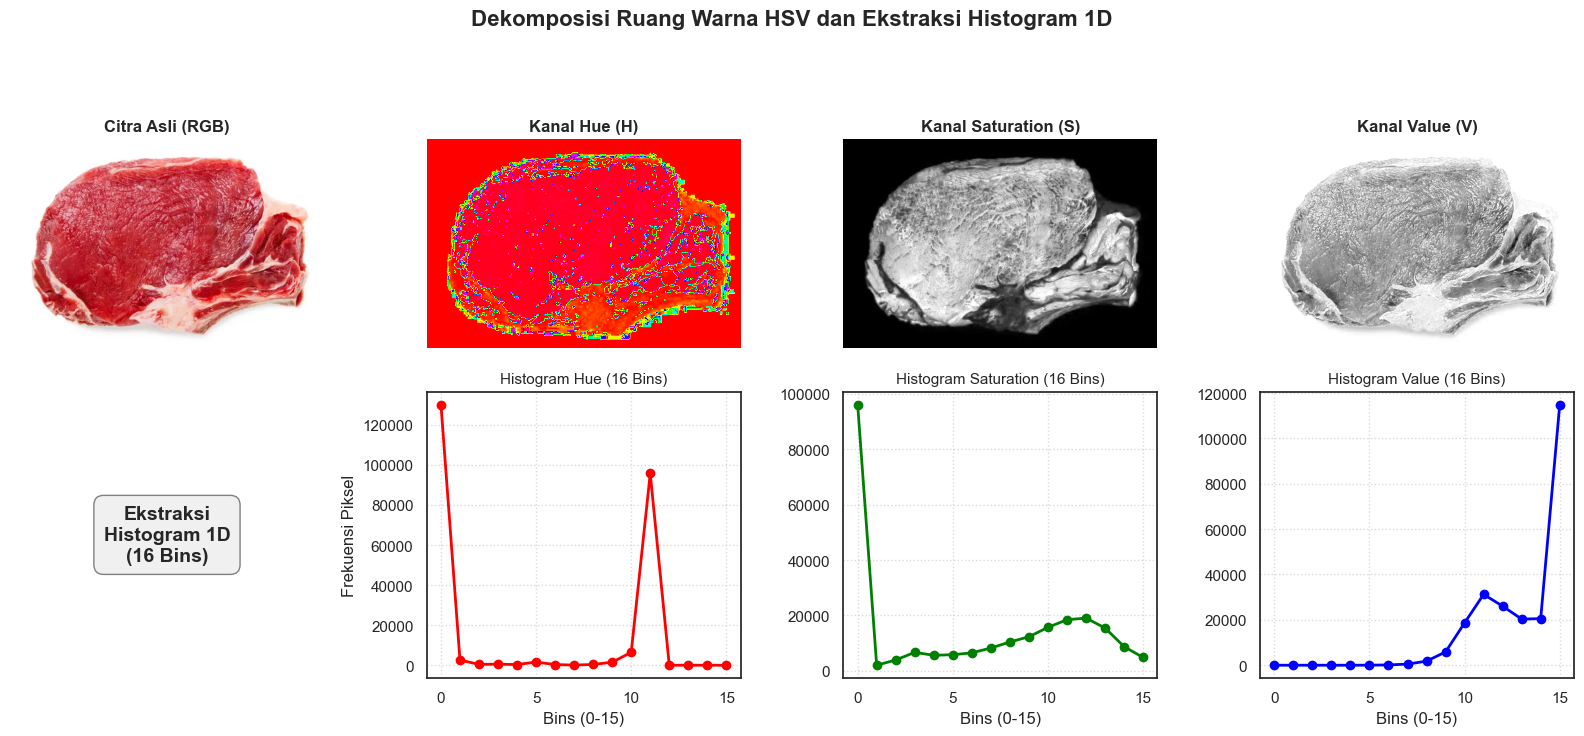

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_hsv_decomposition_for_skripsi(image_path):
    # 1. Baca citra 
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Citra tidak ditemukan di path: {image_path}")
        print("Silakan ganti string image_path dengan gambar daging yang ada di folder Anda.")
        return
    
    # 2. Konversi ke RGB (untuk plot asli) dan HSV (untuk ekstraksi)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # 3. Pisahkan kanal Hue, Saturation, dan Value
    h, s, v = cv2.split(img_hsv)
    
    # 4. Kalkulasi Histogram 1D dengan 16 Bins (Sesuai landasan teori skripsi)
    # Range nilai piksel 0-256 dibagi ke dalam 16 kelompok (bins)
    hist_h = cv2.calcHist([h], [0], None, [16], [0, 256])
    hist_s = cv2.calcHist([s], [0], None, [16], [0, 256])
    hist_v = cv2.calcHist([v], [0], None, [16], [0, 256])
    
    # 5. Inisialisasi Kanvas Plotting (2 Baris x 4 Kolom)
    fig = plt.figure(figsize=(16, 7))
    plt.suptitle("Dekomposisi Ruang Warna HSV dan Ekstraksi Histogram 1D", fontsize=16, fontweight='bold', y=1.05)
    
    # --- BARIS 1: VISUALISASI CITRA ---
    # Citra Asli
    plt.subplot(2, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli (RGB)', fontweight='bold', fontsize=12)
    plt.axis('off')
    
    # Kanal Hue (menggunakan colormap hsv agar terlihat representasinya)
    plt.subplot(2, 4, 2)
    plt.imshow(h, cmap='hsv') 
    plt.title('Kanal Hue (H)', fontweight='bold', fontsize=12)
    plt.axis('off')
    
    # Kanal Saturation (grayscale)
    plt.subplot(2, 4, 3)
    plt.imshow(s, cmap='gray')
    plt.title('Kanal Saturation (S)', fontweight='bold', fontsize=12)
    plt.axis('off')
    
    # Kanal Value (grayscale)
    plt.subplot(2, 4, 4)
    plt.imshow(v, cmap='gray')
    plt.title('Kanal Value (V)', fontweight='bold', fontsize=12)
    plt.axis('off')
    
    # --- BARIS 2: VISUALISASI HISTOGRAM ---
    # Kotak Teks Penjelasan
    plt.subplot(2, 4, 5)
    plt.text(0.5, 0.5, "Ekstraksi\nHistogram 1D\n(16 Bins)", 
             fontsize=14, ha='center', va='center', fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='#f0f0f0', edgecolor='gray'))
    plt.axis('off')
    
    # Plot Hist Hue
    plt.subplot(2, 4, 6)
    plt.plot(hist_h, color='red', marker='o', linewidth=2)
    plt.title('Histogram Hue (16 Bins)', fontsize=11)
    plt.xlabel('Bins (0-15)')
    plt.ylabel('Frekuensi Piksel')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Plot Hist Saturation
    plt.subplot(2, 4, 7)
    plt.plot(hist_s, color='green', marker='o', linewidth=2)
    plt.title('Histogram Saturation (16 Bins)', fontsize=11)
    plt.xlabel('Bins (0-15)')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Plot Hist Value
    plt.subplot(2, 4, 8)
    plt.plot(hist_v, color='blue', marker='o', linewidth=2)
    plt.title('Histogram Value (16 Bins)', fontsize=11)
    plt.xlabel('Bins (0-15)')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    
    # 6. Simpan Otomatis ke file .png dengan resolusi tinggi (300 DPI)
    nama_file_output = "Gambar_3_Visualisasi_HSV.png"
    plt.savefig(nama_file_output, dpi=300, bbox_inches='tight')
    print(f"Visualisasi berhasil dibuat dan disimpan sebagai: {nama_file_output}")
    
    plt.show()


path_contoh_gambar = "test_img/segar4.webp" # Pastikan file ini ada
plot_hsv_decomposition_for_skripsi(path_contoh_gambar)